In [ ]:

import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Sahrul Ramadhani'
NIM = '244107020058'
N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Sahrul Ramadhani
NIM : 244107020058 | N = 58
bins   : 32
clip   : 2.5
tile   : 4
L      : 4
WAKTU : 2026-10-02 00:12:14 WIB
SISTEM : 3.13.15 Windows-11-10.0.26200-SP0
TOKEN : cd15330843fc84cf


# Modul 5: Histogram, Histogram Equalization, dan Dithering

## Identitas

Nama: Sahrul Ramadhani  
NIM: 244107020058  
Kelas: TI 3C

## Persiapan folder citra

`CONTOH` berisi `lena.jpg` dan `lena_lc.jpg`. `BASE` berisi empat citra KTM hasil akuisisi sendiri.

In [ ]:
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CONTOH = '/content/drive/MyDrive/PCVK/Minggu 5/images'
    BASE = CONTOH + '/' + NIM
else:
    CONTOH = str(Path.cwd() / 'tmp' / 'modul5_test' / 'Images')
    BASE = str(Path.cwd() / 'tmp' / 'modul5_test' / 'Images' / NIM)

def check_file(folder, filename):
    path = Path(folder) / filename
    if not path.is_file():
        raise FileNotFoundError(f'File wajib tidak ditemukan: {path}')
    return str(path)

example_files = ['lena.jpg', 'lena_lc.jpg']
ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
for filename in example_files:
    check_file(CONTOH, filename)
for filename in ktm_files:
    check_file(BASE, filename)
print('CONTOH:', CONTOH)
print('BASE   :', BASE)
print('PARAM  :', PARAM)

CONTOH: D:\Pengolahan Citra dan Visi Komputer\tmp\modul5_test\Images
BASE   : D:\Pengolahan Citra dan Visi Komputer\tmp\modul5_test\Images\244107020058
PARAM  : {'bins': 32, 'clip': 2.5, 'tile': 4, 'L': 4}


Ukuran citra contoh: (348, 424, 3) (348, 424, 3)
Ukuran citra KTM: {'KTM1a.jpg': (508, 319, 3), 'KTM1b.jpg': (508, 319, 3), 'KTM1c.jpg': (508, 319, 3), 'KTM1d.jpg': (508, 319, 3)}


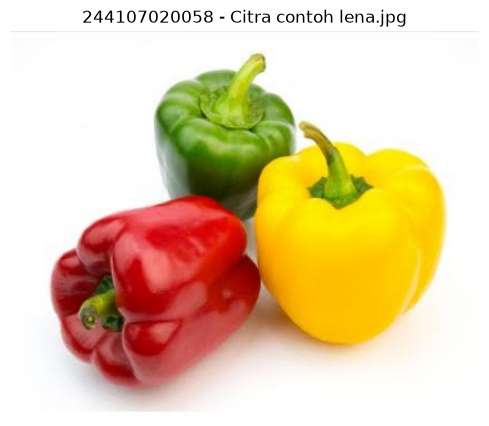

In [ ]:
def read_bgr(folder, filename):
    path = check_file(folder, filename)
    image = cv.imread(path, cv.IMREAD_COLOR)
    if image is None:
        raise ValueError(f'Citra tidak dapat dibaca: {path}')
    return image

def read_gray(folder, filename):
    path = check_file(folder, filename)
    image = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f'Citra tidak dapat dibaca: {path}')
    return image

def judul(text):
    return f'{NIM} - {text}'

def show_bgr(image, text):
    plt.figure(figsize=(7, 5))
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(judul(text))
    plt.axis('off')
    plt.show()

def show_gray(image, text):
    plt.figure(figsize=(7, 5))
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(judul(text))
    plt.axis('off')
    plt.show()

lena = read_bgr(CONTOH, 'lena.jpg')
lena_lc = read_bgr(CONTOH, 'lena_lc.jpg')
ktm = {name: read_bgr(BASE, name) for name in ktm_files}
print('Ukuran citra contoh:', lena.shape, lena_lc.shape)
print('Ukuran citra KTM:', {name: image.shape for name, image in ktm.items()})
show_bgr(lena, 'Citra contoh lena.jpg')

## E-1. Percobaan Histogram

Histogram grayscale memiliki satu grafik. Histogram citra warna memiliki satu grafik untuk setiap channel. Histogram ternormalisasi dihitung dengan `p(j) = h(j) / (M × N)` dan CDF dihitung dengan penjumlahan kumulatif.

In [ ]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[int(img[y, x])] += 1
    return h

def histogram_numpy(gray, L=256):
    return np.histogram(gray, bins=L, range=(0, L))[0].astype(np.int64)

def histogram_opencv(gray, L=256):
    return cv.calcHist([gray], [0], None, [L], [0, L]).ravel().astype(np.int64)

def probability_cdf(gray, L=256):
    h = histogram_manual(gray, L)
    p = h / gray.size
    cdf = np.cumsum(p)
    return h, p, cdf

def verify_histogram(folder, filename):
    gray = read_gray(folder, filename)
    h_manual = histogram_manual(gray)
    h_numpy = histogram_numpy(gray)
    h_opencv = histogram_opencv(gray)
    diff_numpy = int(np.max(np.abs(h_manual - h_numpy)))
    diff_opencv = int(np.max(np.abs(h_manual - h_opencv)))
    assert h_manual.sum() == gray.size
    print(filename, '| manual-Numpy:', diff_numpy, '| manual-cv.calcHist:', diff_opencv)
    return gray, h_manual, h_numpy, h_opencv

lena_gray, lena_h, lena_h_numpy, lena_h_cv = verify_histogram(CONTOH, 'lena.jpg')
ktm1b_gray, ktm1b_h, ktm1b_h_numpy, ktm1b_h_cv = verify_histogram(BASE, 'KTM1b.jpg')

lena.jpg | manual-Numpy: 0 | manual-cv.calcHist: 0
KTM1b.jpg | manual-Numpy: 0 | manual-cv.calcHist: 0


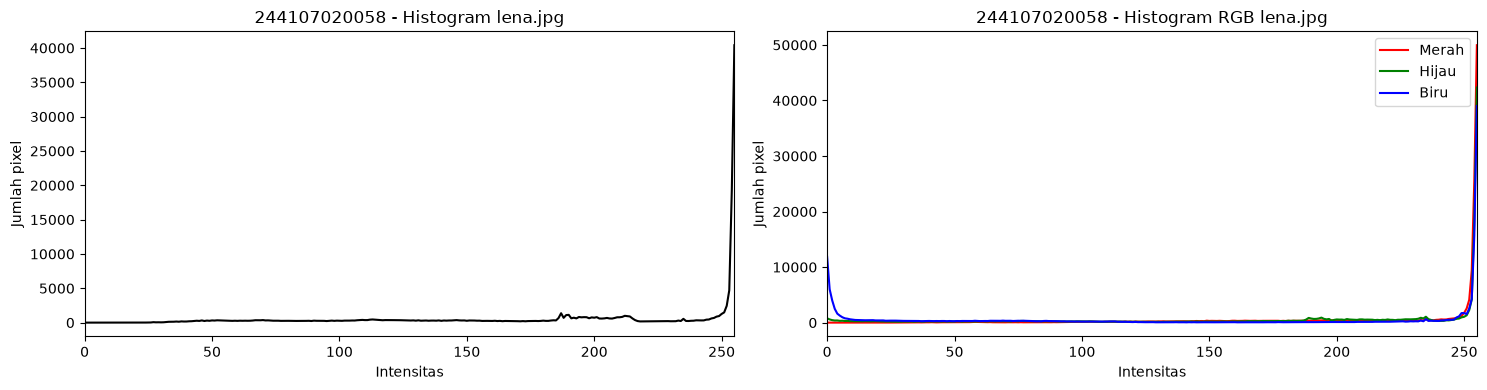

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(lena_h, color='black')
axes[0].set_title(judul('Histogram lena.jpg'))
axes[0].set_xlabel('Intensitas')
axes[0].set_ylabel('Jumlah pixel')
axes[0].set_xlim(0, 255)
rgb_lena = cv.cvtColor(lena, cv.COLOR_BGR2RGB)
for index, (name, color) in enumerate(zip(('Merah', 'Hijau', 'Biru'), ('red', 'green', 'blue'))):
    axes[1].plot(histogram_manual(rgb_lena[:, :, index]), color=color, label=name)
axes[1].set_title(judul('Histogram RGB lena.jpg'))
axes[1].set_xlabel('Intensitas')
axes[1].set_ylabel('Jumlah pixel')
axes[1].set_xlim(0, 255)
axes[1].legend()
plt.tight_layout()
plt.show()

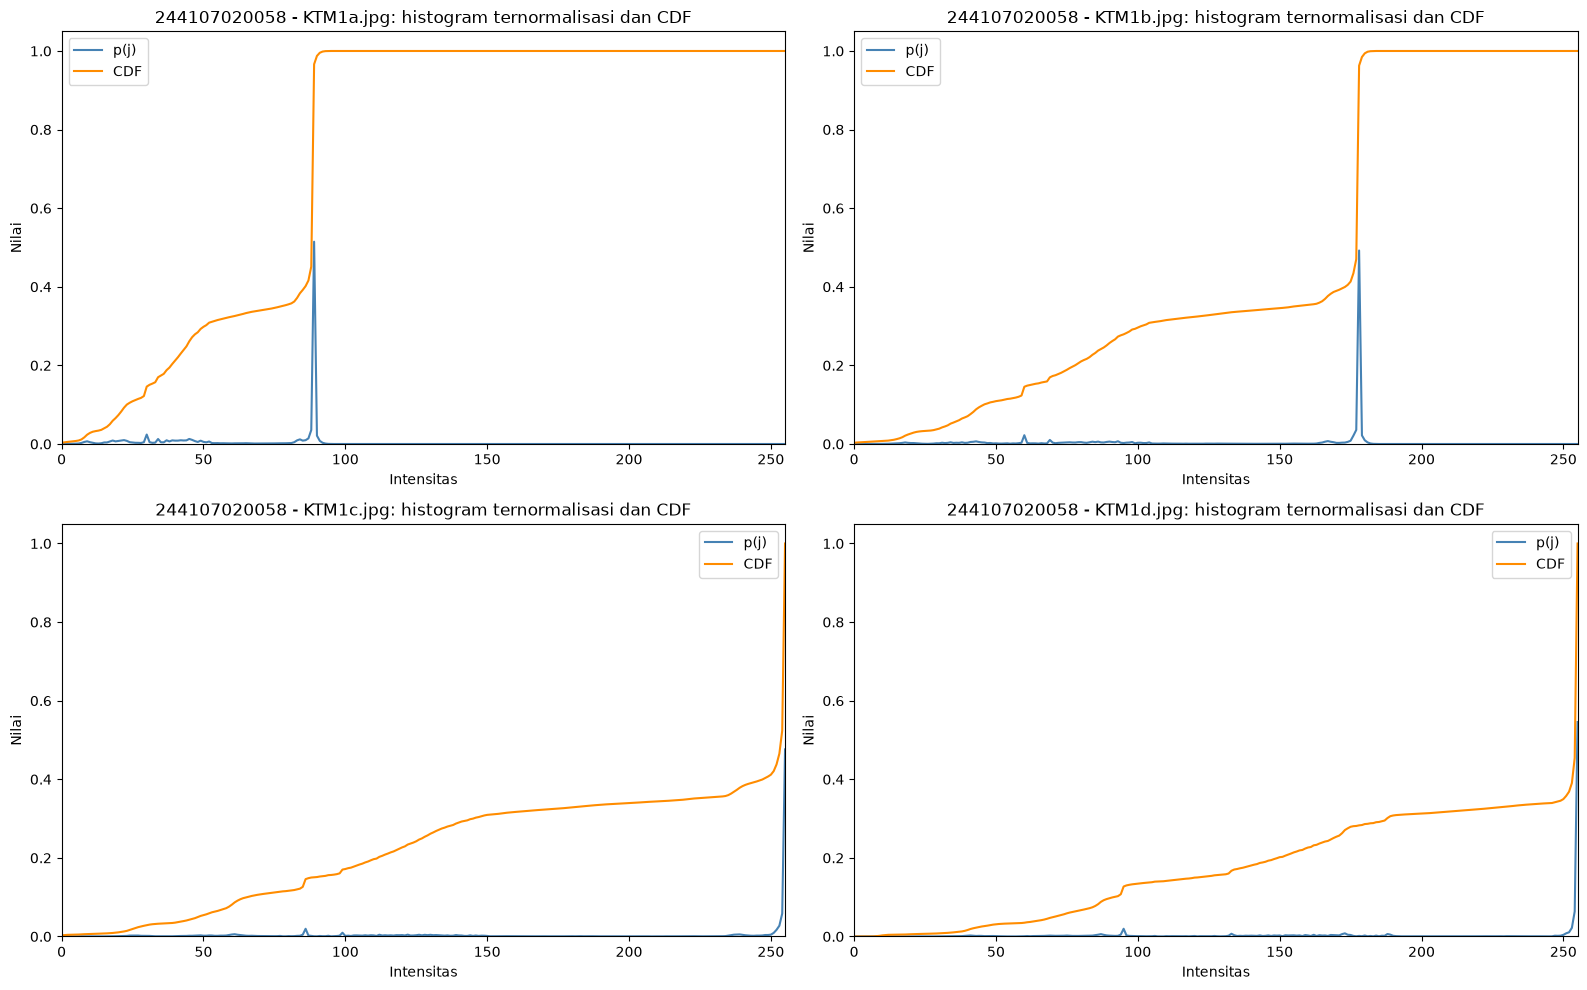

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (filename, image) in zip(axes.ravel(), ktm.items()):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    h, p, cdf = probability_cdf(gray)
    ax.plot(np.arange(256), p, color='steelblue', label='p(j)')
    ax.plot(np.arange(256), cdf, color='darkorange', label='CDF')
    ax.set_title(judul(f'{filename}: histogram ternormalisasi dan CDF'))
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Nilai')
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 1.05)
    ax.legend()
plt.tight_layout()
plt.show()

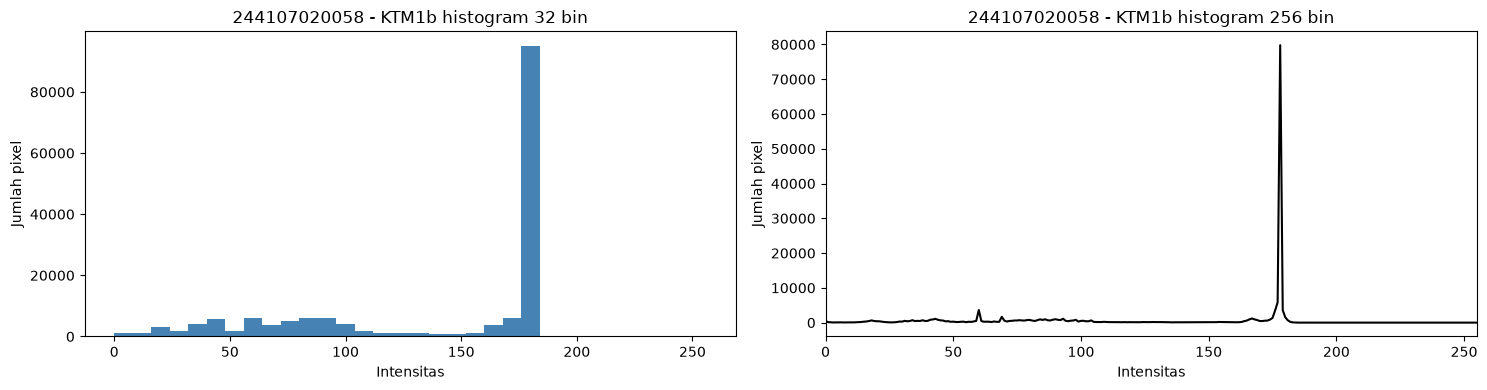

Bin personal: 32 | bin 256: 256
Saat bin dikurangi, detail perubahan intensitas kecil bergabung ke satu kelompok.


In [ ]:
bins_personal = PARAM['bins']
hist_personal, edges_personal = np.histogram(ktm1b_gray, bins=bins_personal, range=(0, 256))
hist_256, edges_256 = np.histogram(ktm1b_gray, bins=256, range=(0, 256))
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].bar(edges_personal[:-1], hist_personal, width=256 / bins_personal, color='steelblue', align='edge')
axes[0].set_title(judul(f'KTM1b histogram {bins_personal} bin'))
axes[0].set_xlabel('Intensitas')
axes[0].set_ylabel('Jumlah pixel')
axes[1].plot(np.arange(256), hist_256, color='black')
axes[1].set_title(judul('KTM1b histogram 256 bin'))
axes[1].set_xlabel('Intensitas')
axes[1].set_ylabel('Jumlah pixel')
axes[1].set_xlim(0, 255)
plt.tight_layout()
plt.show()
print('Bin personal:', bins_personal, '| bin 256:', 256)
print('Saat bin dikurangi, detail perubahan intensitas kecil bergabung ke satu kelompok.')

## E-2. Percobaan Histogram Equalization

lena_lc.jpg | selisih maksimum manual-cv.equalizeHist: 1


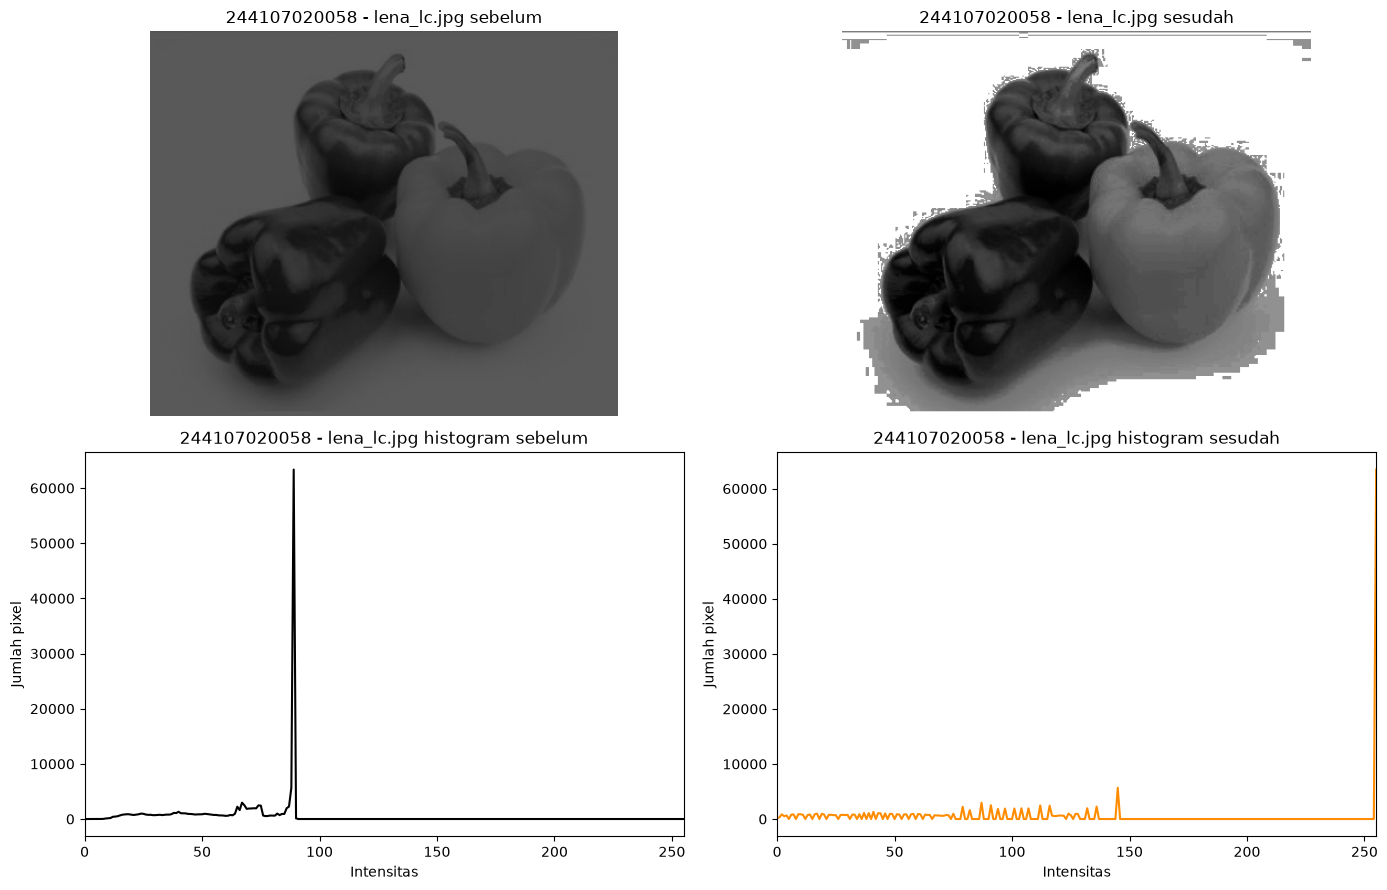

KTM1a.jpg | selisih maksimum manual-cv.equalizeHist: 1


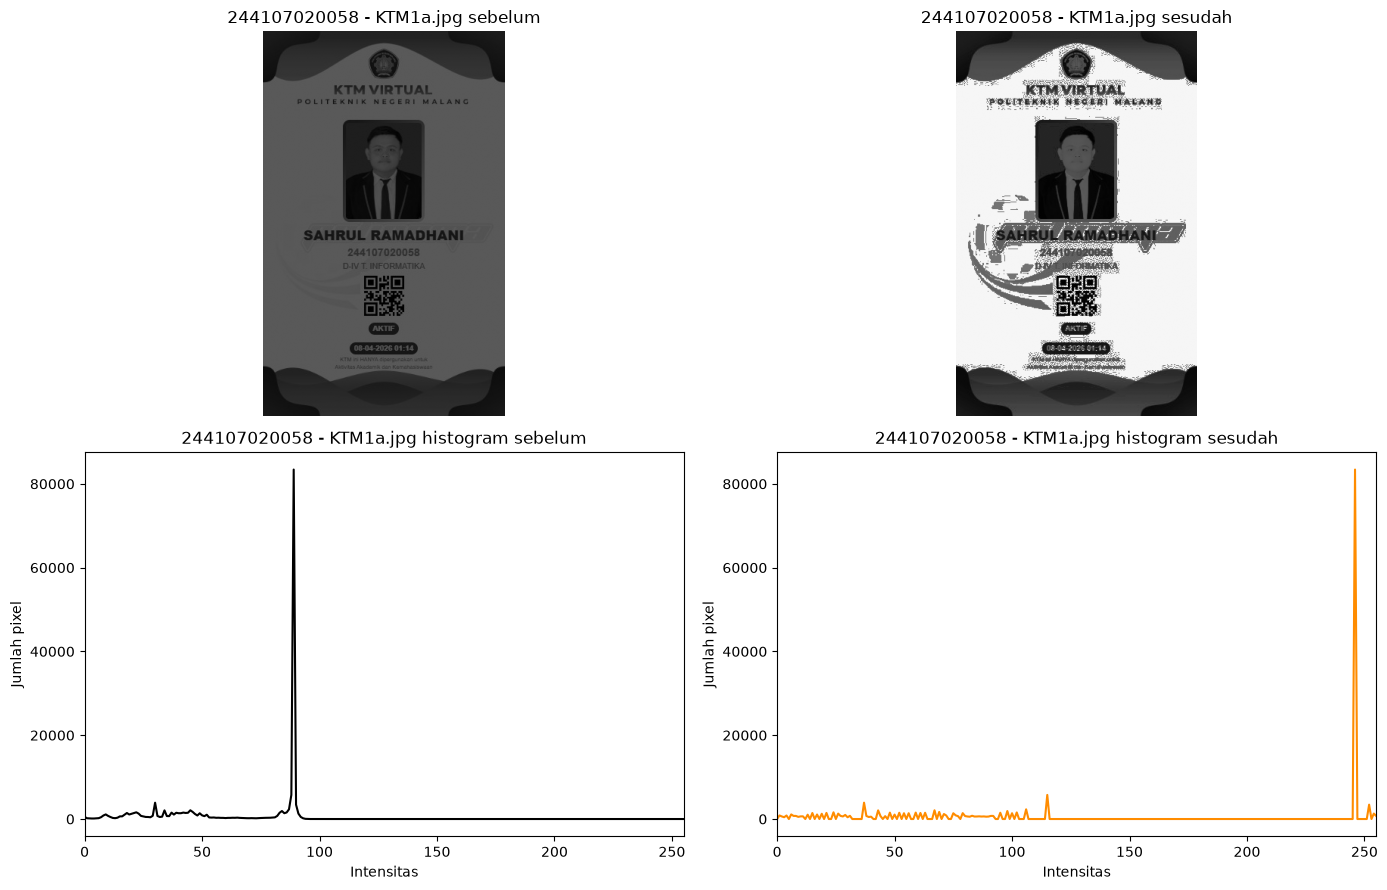

Perbedaan manual dan OpenCV dapat muncul bila implementasi memakai pembulatan atau LUT yang berbeda.


In [ ]:
def equalize_manual(gray, L=256):
    gray = np.asarray(gray, dtype=np.uint8)
    h = histogram_manual(gray, L)
    cdf = np.cumsum(h) / gray.size
    lut = np.rint((L - 1) * cdf).astype(np.uint8)
    return lut[gray], h, cdf, lut

def show_equalization(gray, result, title, h_before, h_after):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].imshow(gray, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(judul(title + ' sebelum'))
    axes[0, 1].imshow(result, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(judul(title + ' sesudah'))
    axes[1, 0].plot(h_before, color='black')
    axes[1, 0].set_title(judul(title + ' histogram sebelum'))
    axes[1, 1].plot(h_after, color='darkorange')
    axes[1, 1].set_title(judul(title + ' histogram sesudah'))
    for ax in axes[0]:
        ax.axis('off')
    for ax in axes[1]:
        ax.set_xlim(0, 255)
        ax.set_xlabel('Intensitas')
        ax.set_ylabel('Jumlah pixel')
    plt.tight_layout()
    plt.show()

def compare_equalization(folder, filename):
    gray = read_gray(folder, filename)
    manual, h_before, _, _ = equalize_manual(gray)
    opencv = cv.equalizeHist(gray)
    difference = int(np.max(np.abs(manual.astype(np.int16) - opencv.astype(np.int16))))
    h_after = histogram_manual(manual)
    print(filename, '| selisih maksimum manual-cv.equalizeHist:', difference)
    show_equalization(gray, manual, filename, h_before, h_after)
    return gray, manual, opencv

lena_lc_gray, lena_lc_equalized, lena_lc_cv_equalized = compare_equalization(CONTOH, 'lena_lc.jpg')
ktm1a_gray, ktm1a_equalized, ktm1a_cv_equalized = compare_equalization(BASE, 'KTM1a.jpg')
print('Perbedaan manual dan OpenCV dapat muncul bila implementasi memakai pembulatan atau LUT yang berbeda.')

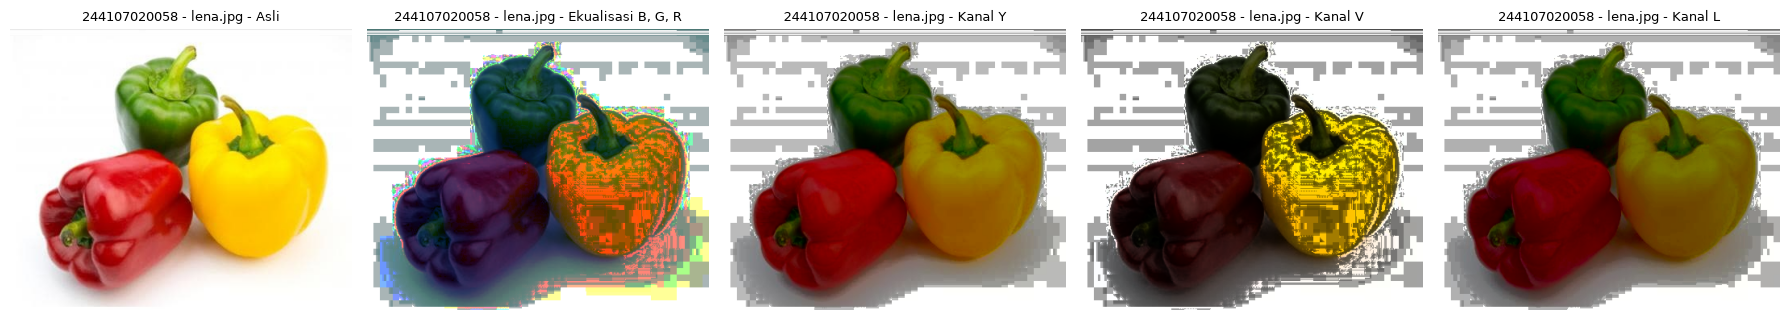

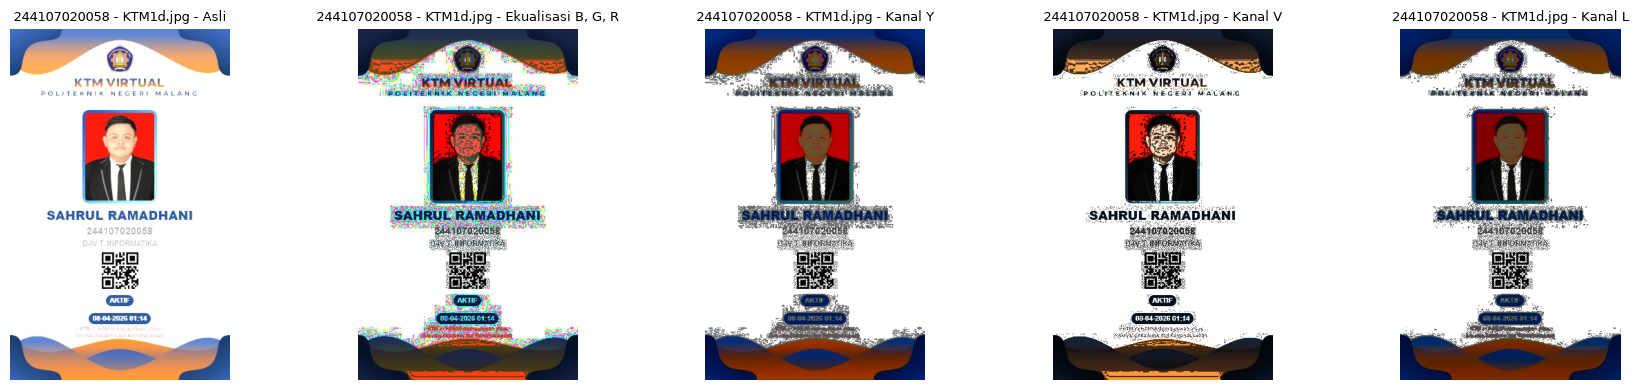

In [ ]:
def color_equalization(image):
    channels = list(cv.split(image))
    channels = [cv.equalizeHist(channel) for channel in channels]
    he_rgb = cv.merge(channels)

    ycrcb = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(image, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
    return [image, he_rgb, he_y, he_v, he_l]

def show_color_results(image, filename):
    labels = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    results = color_equalization(image)
    plt.figure(figsize=(18, 4))
    for i, (result, label) in enumerate(zip(results, labels), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
        plt.title(judul(filename + ' - ' + label), fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return results

lena_color_results = show_color_results(lena, 'lena.jpg')
ktm1d_color = read_bgr(BASE, 'KTM1d.jpg')
ktm1d_color_results = show_color_results(ktm1d_color, 'KTM1d.jpg')

In [ ]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return float(d.mean() * 2)

def rerata_terang(image):
    return float(cv.cvtColor(image, cv.COLOR_BGR2GRAY).mean())

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for label, result in zip(['Citra asli', 'Ekualisasi kanal B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L'], ktm1d_color_results):
    print('%-22s %16.2f %16.1f' % (label, geser_hue(ktm1d_color, result), rerata_terang(result)))
print('Pergeseran Hue dihitung pada jalur terpendek karena Hue OpenCV melingkar 0 sampai 179.')

Cara                    geser Hue (der)    rerata terang
Citra asli                         0.00            211.8
Ekualisasi kanal B, G, R            14.66            173.2
Kanal Y                            2.18            167.3
Kanal V                            0.91            179.8
Kanal L                            7.53            169.5
Pergeseran Hue dihitung pada jalur terpendek karena Hue OpenCV melingkar 0 sampai 179.


CLAHE KTM1d | clipLimit: 2.5 | tileGridSize: (4, 4)
CLAHE KTM1d | geser Hue: 1.33 derajat | rerata terang: 209.7


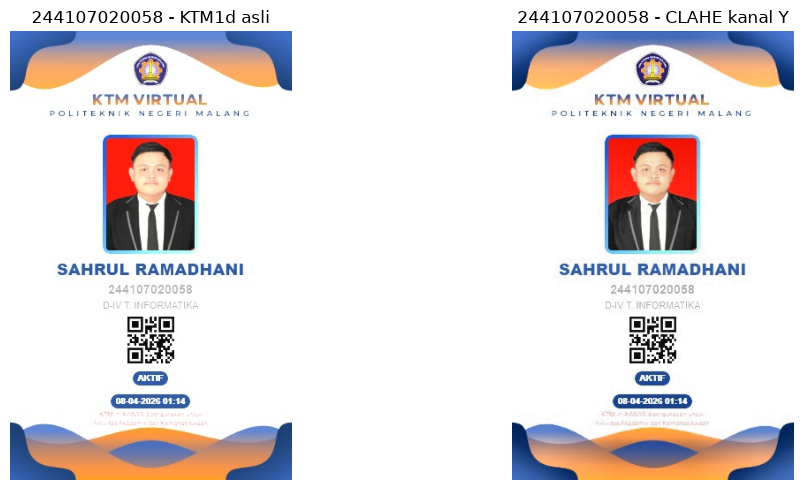

In [ ]:
def equalize_y_clahe(image, clip_limit, tile):
    ycrcb = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    clahe = cv.createCLAHE(clipLimit=float(clip_limit), tileGridSize=(int(tile), int(tile)))
    return cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

clahe_ktm1d = equalize_y_clahe(ktm1d_color, PARAM['clip'], PARAM['tile'])
print('CLAHE KTM1d | clipLimit:', PARAM['clip'], '| tileGridSize:', (PARAM['tile'], PARAM['tile']))
print('CLAHE KTM1d | geser Hue:', '%.2f derajat' % geser_hue(ktm1d_color, clahe_ktm1d), '| rerata terang:', '%.1f' % rerata_terang(clahe_ktm1d))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, image, title in zip(axes, [ktm1d_color, clahe_ktm1d], ['KTM1d asli', 'CLAHE kanal Y']):
    ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    ax.set_title(judul(title))
    ax.axis('off')
plt.tight_layout()
plt.show()

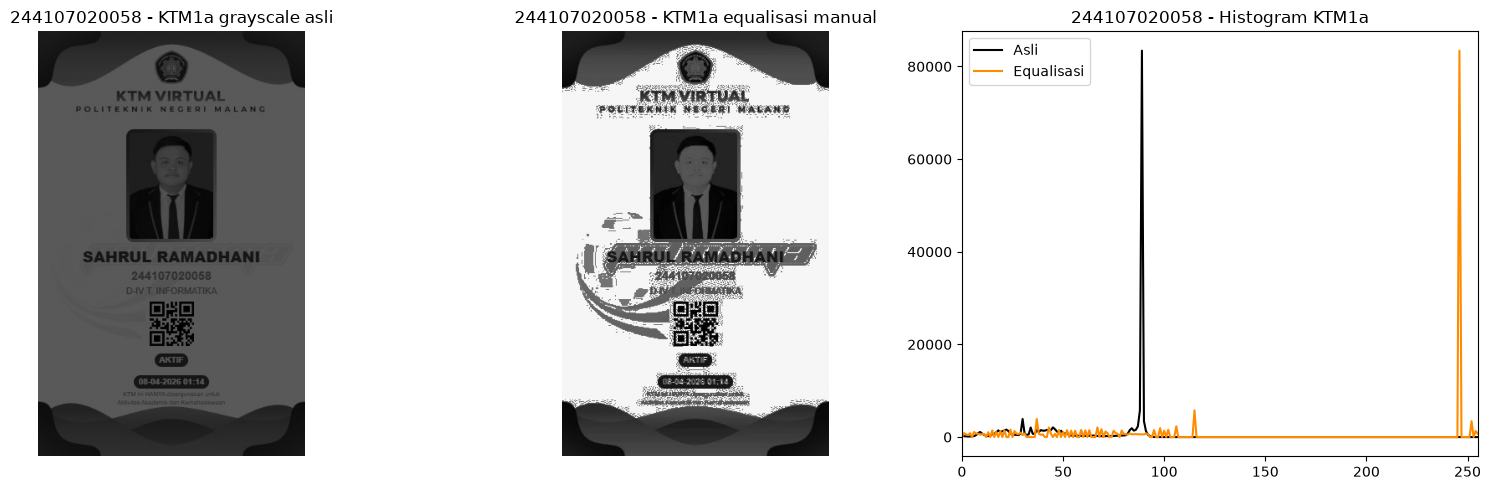

PSNR KTM1a asli terhadap hasil equalization: 6.766677134284728 dB
PSNR dapat turun karena equalization mengubah intensitas untuk memperjelas kontras; PSNR bukan ukuran keterbacaan.


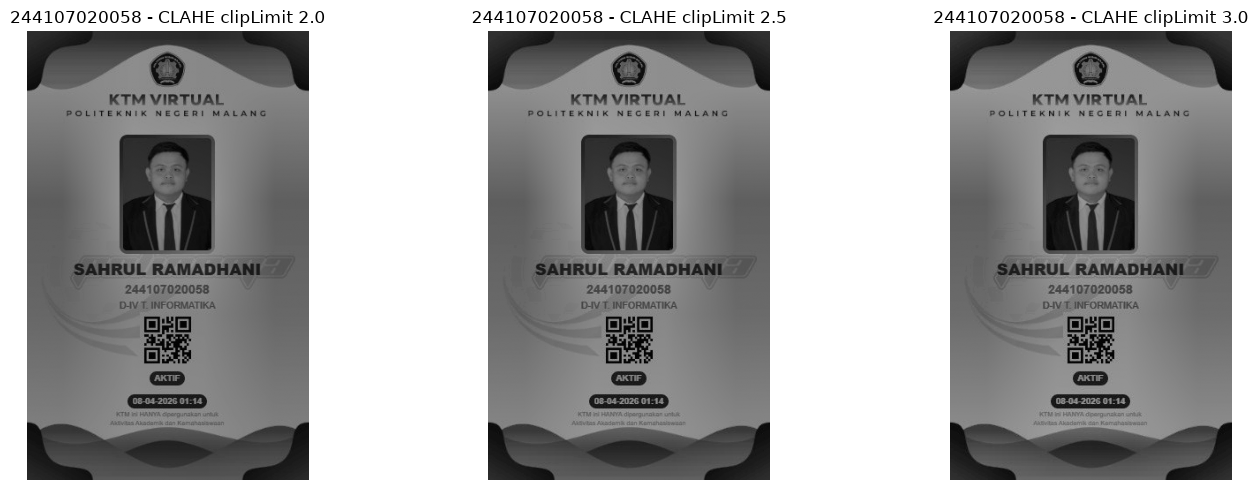

Nilai clipLimit yang diuji: [2.0, 2.5, 3.0]
Nilai terbaik dipilih dari hasil yang paling jelas dengan noise paling sedikit.


In [ ]:
psnr_ktm1a = cv.PSNR(ktm1a_gray, ktm1a_equalized)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(ktm1a_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(judul('KTM1a grayscale asli'))
axes[1].imshow(ktm1a_equalized, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(judul('KTM1a equalisasi manual'))
axes[2].plot(histogram_manual(ktm1a_gray), color='black', label='Asli')
axes[2].plot(histogram_manual(ktm1a_equalized), color='darkorange', label='Equalisasi')
axes[2].set_title(judul('Histogram KTM1a'))
axes[2].set_xlim(0, 255)
axes[2].legend()
for ax in axes[:2]:
    ax.axis('off')
plt.tight_layout()
plt.show()
print('PSNR KTM1a asli terhadap hasil equalization:', psnr_ktm1a, 'dB')
print('PSNR dapat turun karena equalization mengubah intensitas untuk memperjelas kontras; PSNR bukan ukuran keterbacaan.')

clip_values = sorted(set([max(0.1, PARAM['clip'] - 0.5), PARAM['clip'], PARAM['clip'] + 0.5]))
clahe_results = []
fig, axes = plt.subplots(1, len(clip_values), figsize=(15, 5))
for ax, clip_value in zip(np.atleast_1d(axes), clip_values):
    clahe = cv.createCLAHE(clipLimit=float(clip_value), tileGridSize=(PARAM['tile'], PARAM['tile']))
    result = clahe.apply(ktm1a_gray)
    clahe_results.append(result)
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(judul('CLAHE clipLimit ' + str(clip_value)))
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Nilai clipLimit yang diuji:', clip_values)
print('Nilai terbaik dipilih dari hasil yang paling jelas dengan noise paling sedikit.')

## E-3. Tugas Praktikum Dithering

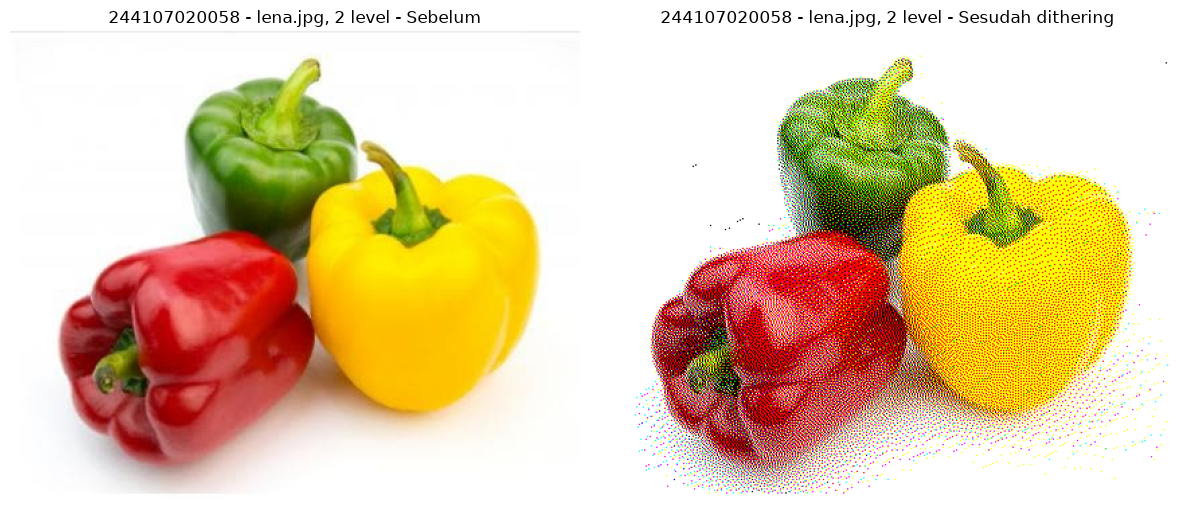

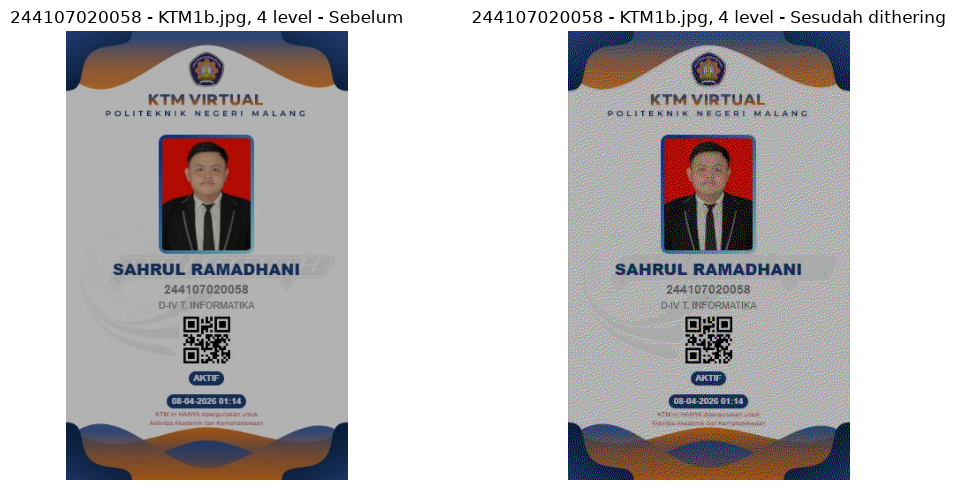

Jumlah level KTM1b: 4


In [ ]:
def floyd_steinberg_channel(channel, levels):
    if levels < 2:
        raise ValueError('Jumlah level minimal 2')
    work = channel.astype(np.float64).copy()
    step = 255.0 / (levels - 1)
    height, width = work.shape
    for y in range(height):
        for x in range(width):
            old = work[y, x]
            new = np.clip(np.round(old / step) * step, 0, 255)
            error = old - new
            work[y, x] = new
            for dy, dx, weight in [(0, 1, 7 / 16), (1, -1, 3 / 16), (1, 0, 5 / 16), (1, 1, 1 / 16)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < height and 0 <= nx < width:
                    work[ny, nx] = np.clip(work[ny, nx] + error * weight, 0, 255)
    return np.clip(np.rint(work), 0, 255).astype(np.uint8)

def floyd_steinberg(image, levels):
    if image.ndim == 2:
        return floyd_steinberg_channel(image, levels)
    channels = cv.split(image)
    return cv.merge([floyd_steinberg_channel(channel, levels) for channel in channels])

def show_before_after(before, after, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, image, label in zip(axes, [before, after], ['Sebelum', 'Sesudah dithering']):
        if image.ndim == 2:
            ax.imshow(image, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        ax.set_title(judul(title + ' - ' + label))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

lena_dither_2 = floyd_steinberg(lena, 2)
show_before_after(lena, lena_dither_2, 'lena.jpg, 2 level')
ktm1b_dither = floyd_steinberg(read_bgr(BASE, 'KTM1b.jpg'), PARAM['L'])
show_before_after(ktm['KTM1b.jpg'], ktm1b_dither, 'KTM1b.jpg, ' + str(PARAM['L']) + ' level')
print('Jumlah level KTM1b:', PARAM['L'])

In [ ]:
def verify_one_pixel():
    pixel = 130.0
    step = 255.0
    nearest = np.round(pixel / step) * step
    error = pixel - nearest
    values = {
        'nearest': nearest,
        'error': error,
        'right': error * 7 / 16,
        'bottom-left': error * 3 / 16,
        'bottom': error * 5 / 16,
        'bottom-right': error * 1 / 16,
    }
    print(values)
    print('Jumlah sebaran error:', sum(values[key] for key in ['right', 'bottom-left', 'bottom', 'bottom-right']))
    assert np.isclose(values['nearest'], 255)
    assert np.isclose(values['error'], -125)
    assert np.isclose(sum(values[key] for key in ['right', 'bottom-left', 'bottom', 'bottom-right']), -125)

verify_one_pixel()

{'nearest': np.float64(255.0), 'error': np.float64(-125.0), 'right': np.float64(-54.6875), 'bottom-left': np.float64(-23.4375), 'bottom': np.float64(-39.0625), 'bottom-right': np.float64(-7.8125)}
Jumlah sebaran error: -125.0


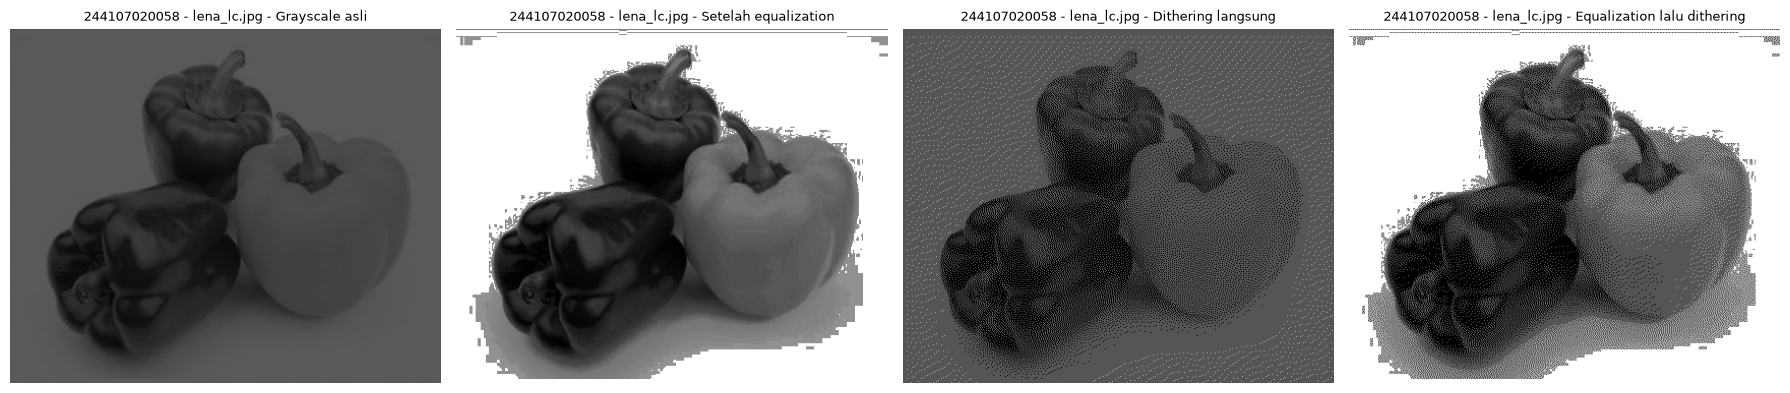

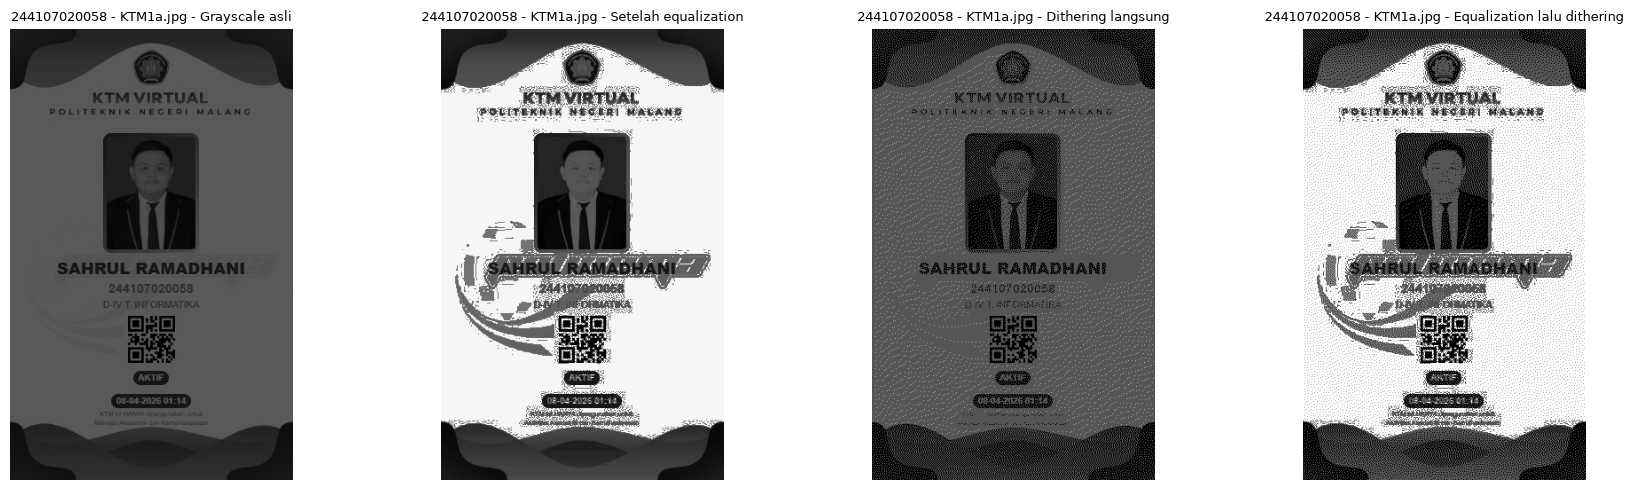

Perbandingan keterbacaan KTM dilakukan pada dua keluaran terakhir; equalization lebih dulu membantu saat teks berada di bagian gelap.


In [ ]:
def grayscale_equalized_dither(folder, filename, levels):
    gray = read_gray(folder, filename)
    equalized, _, _, _ = equalize_manual(gray)
    direct = floyd_steinberg(gray, levels)
    after_equalization = floyd_steinberg(equalized, levels)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    images = [gray, equalized, direct, after_equalization]
    labels = ['Grayscale asli', 'Setelah equalization', 'Dithering langsung', 'Equalization lalu dithering']
    for ax, image, label in zip(axes, images, labels):
        ax.imshow(image, cmap='gray', vmin=0, vmax=255)
        ax.set_title(judul(filename + ' - ' + label), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return gray, equalized, direct, after_equalization

lena_lc_dither_results = grayscale_equalized_dither(CONTOH, 'lena_lc.jpg', PARAM['L'])
ktm1a_dither_results = grayscale_equalized_dither(BASE, 'KTM1a.jpg', PARAM['L'])
print('Perbandingan keterbacaan KTM dilakukan pada dua keluaran terakhir; equalization lebih dulu membantu saat teks berada di bagian gelap.')